!!!!
- Ich bin im Skript der Learning Journey gefolgt
- am Ende passen die ARIMA - Parameter aber gar nicht, die kompliziert ermittelt wurden
- damit sind die SARIMA - Parameter sicher auch nicht toll
- habe beide Modelle im Skript "Statistical_Models" nochmal kurz und bündig gestartet

# Daten vorbereiten
## ...

DARTS ist eine speziell für Zeitreihenprognosen entwickelte Python-Bibliothek. Sie bietet eine Vielzahl an Modellen, darunter klassische Modelle (ARIMA, exponentielle Glättung), Machine-Learning-Modelle und sogar Deep-Learning-Modelle. Der Hauptvorteil von DARTS ist die Vereinfachung des Modelltrainings und der Evaluation für Zeitreihen.

In [1]:
import pandas as pd
import numpy as np

In [2]:
path = '../Data/'

df_filtered = pd.read_csv(path + 'timeseries.csv')

# ...
df_filtered['date'] = pd.to_datetime(df_filtered['date'])

# Nach Datum gruppieren und tägliche Verkäufe aggregieren
# => eigentlich gar nicht nötig, da eh nur ein Eintrag je Tag
df_filtered = df_filtered.groupby('date').sum()['unit_sales'].reset_index()

# Column 'date' in den Index bringen
df_filtered.set_index('date', inplace=True)

df_filtered.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 452 entries, 2013-01-02 to 2014-03-31
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unit_sales  452 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


In [3]:
# Fehlende Daten (Tage ohne Verkäufe) mit 0 füllen
# => wie letzte Woche gesehen betrifft das 2 Tage
df_filtered = df_filtered.asfreq('D').fillna(0)

# In ein TimeSeries-Objekt von Darts umwandeln um anschließend zu modelln und evaluieren
from darts import TimeSeries

series = TimeSeries.from_dataframe(df_filtered, value_cols='unit_sales')

<Axes: xlabel='date'>

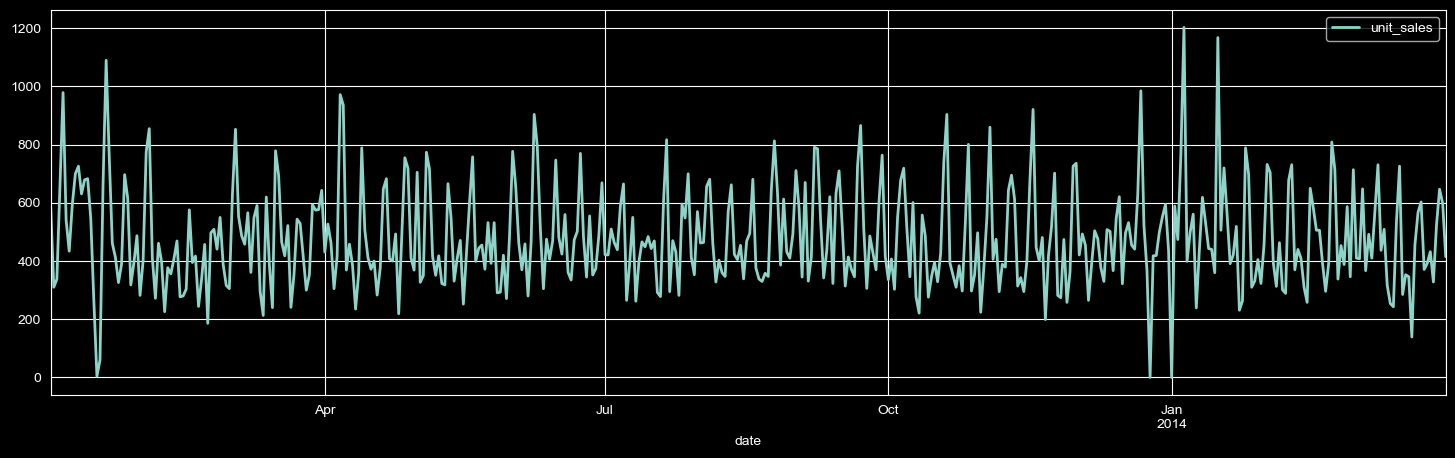

In [4]:
import matplotlib.pyplot as plt

# Visualisiere die gefilterten Verkaufsdaten
plt.figure(figsize=(18, 5))  # Größe der Abbildung anpassen (Breite, Höhe)
series.plot()


## Aufteilen in Trainings- und Testdaten

In [5]:
# Daten aufteilen (80% Training, 20% Test) mit darts-eigener Methode
train, test = series.split_after(0.8)

## ARIMA
### Nochmal ADF-Test

In [6]:
from statsmodels.tsa.stattools import adfuller

# adfuller() funktioniert nicht direkt mit Darts TimeSeries –
# wir müssen die Werte extrahieren:
arr = train.values().flatten()

result = adfuller(arr)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"ADF p-value: {result[1]:.2e}")
print(f"Critical Values: {result[4]}")

ADF Statistic: -4.2874
ADF p-value: 4.67e-04
Critical Values: {'1%': np.float64(-3.449336554273722), '5%': np.float64(-2.8699055166063085), '10%': np.float64(-2.571226758215748)}


=> wie letzte Woche gesehen haben wir es bereits mit einer stationären Zeitreihe im Sinne der Einheitswurzel (ADF-Test) zu tun

ARIMA Parameter d
- Trend in den Daten => ich muss ihn rausbekommen durch Differenzierung
- wird d-mal durchgeführt, um sie stationär zu machen (gleichmäßiger Mittelwert ohne Trend)
- ! Wie in Week 1 gesehen sind meine Daten laut AFD - Test stationär => Differenzierung nicht nötig

### Parameter d: Differenzierung der Zeitreihe

<Axes: title={'center': 'unit_sales (d=1)'}>

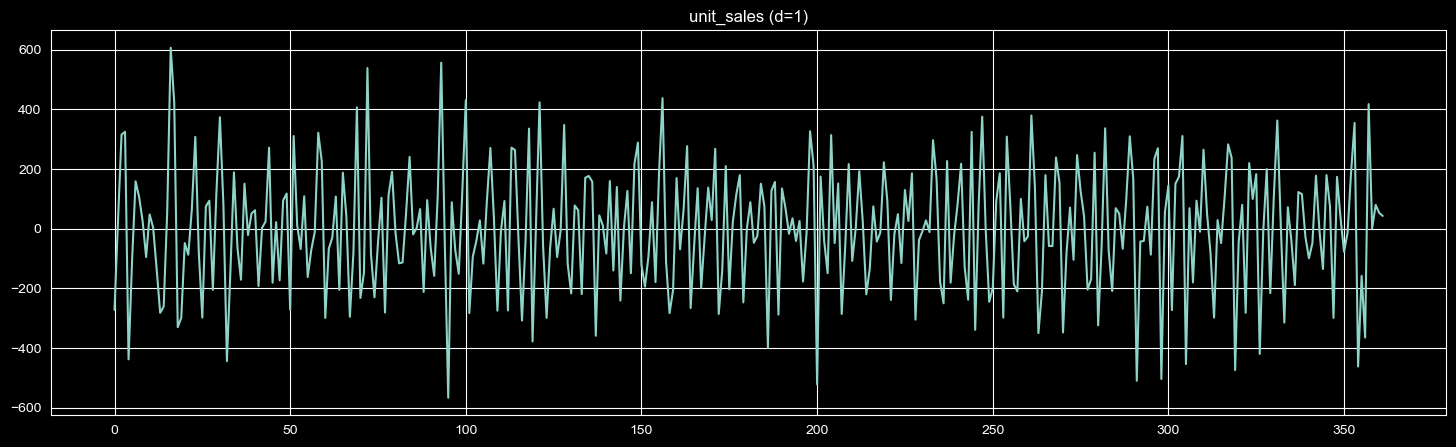

In [7]:
# ZUm SPass obwohl nicht nötig Zeitreihe differenzieren
# Führe die erste Differenzierung durch – das ist unsere neue differenzierte Trainingsreihe
diff1 = np.diff(arr, 1)

pd.Series(diff1).plot(title="unit_sales (d=1)", figsize=(18, 5))

In [8]:
# ADF-Test auf der differenzierten Serie
result = adfuller(diff1)
print("p-Wert der 1. Differenzierung:", result[1])

p-Wert der 1. Differenzierung: 2.5893585918455584e-12


- => p-Wert weiterhin deutlich unter 0.05, nun sogar nach Differenzierung noch bissel kleiner als zuvor
- wäre p-Wert > 0.05, dann würde man d=2 testen
- Achtung: Übermäßiges Differenzieren kann zusätzliches Rauschen erzeugen und Prognosen verschlechtern.

### Parameter p: Vergangene Werte => PACF

- Das „p“ in ARIMA(p, d, q) gibt an, wie viele vergangene Beobachtungen das Modell zur Vorhersage des heutigen Werts verwendet
- Wenn du p = 1 wählst, sagst du: „Der heutige Wert hängt mit dem gestrigen Wert zusammen.“
- Bei p = 7 beziehst du die letzten 7 Tage ein: Heute wird als gewichtete Summe der Verkäufe von gestern, vorgestern, ... bis vor 7 Tagen modelliert (plus dem Fehlerterm).

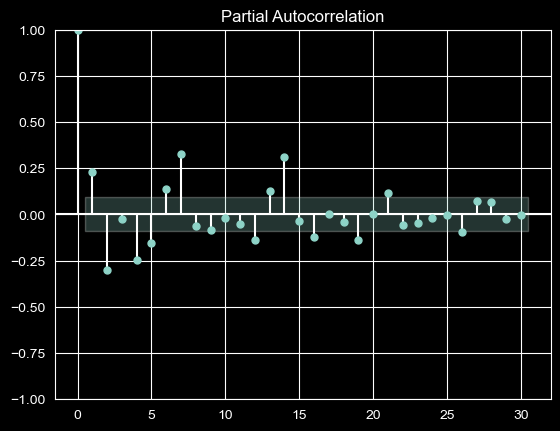

In [9]:
from statsmodels.graphics.tsaplots import plot_pacf

# Wir zeigen Lags bis zu 30 Tagen zurück (≈ 1 Monat)
plot_pacf(df_filtered, lags=30)
plt.show()


- Die Partial Autocorrelation Function (PACF) zeigt dir, wie stark der heutige Wert direkt mit einem bestimmten früheren Tag verknüpft ist, nachdem der Einfluss der Zwischentage herausgerechnet wurde.
- PACF wird NACH Differenzierung durchgeführt!
- Schattierter Bereich: Konfidenzintervall (meist 95 %). Wenn ein Balken AUSSERHALB des schattierten Bereichs liegt, ist er statistisch signifikant.

- Suche das „Abschneiden“ (cut-off):
    - Finde, wo die Balken in den grauen Bereich eintauchen und dort bleiben.
    - Setze p auf diesen cut-off (oder etwas darunter).

was bedeutet das für meine Daten nun:
Lag 1: 0.234 → signifikant
Lag 2: -0.312 → signifikant
Lag 3: nahe 0 → nicht signifikant
lag 4-6 ebenfalls signifikant
Lag 7: 0.331 → saisonaler Spike
Lag 14: 0.347 → saisonaler Spike

=>
- Saisonale Spikes bei Lag 7, 14 bestätigen erneut wöchentliche Saisonalität
- kein sauberer Cut-off.


### Parameter q: Vergangene Fehler => ACF

- Der Moving-Average-Teil (MA) von ARIMA besagt, dass der heutige Wert von vergangenen Prognosefehlern beeinflusst wird (also dem Unterschied zwischen dem, was wir vorhergesagt haben, und dem, was tatsächlich passiert ist).
- erneut: Vorbedingung für alles Folgende ist, das die Zeitreihe stationär ist (AFD-Test...)
- Die Moving-Average-Komponente (MA) passt die heutige Vorhersage anhand vergangener Prognosefehler an. Der ACF-Plot zeigt, wie lange sich diese Fehler auswirken.

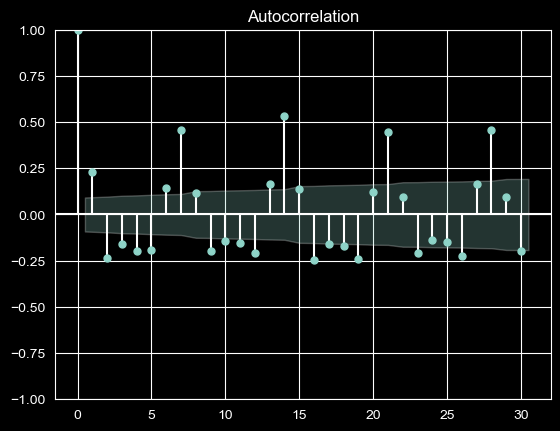

In [10]:
# Autokorrelationsfunktion (ACF)
# Die Autokorrelationsfunktion (ACF) misst, wie der heutige Wert mit allen früheren Tagen zusammenhängt – direkt und indirekt.
from statsmodels.graphics.tsaplots import plot_acf

# Wir betrachten bis zu 30 Lags zurück
plot_acf(df_filtered, lags=30)
plt.show()

INTERPRETATION:

(a) Wöchentliche Saisonalität klar sichtbar:
Lag 7: 0.46 → starker positiver Spike
Lag 14: 0.55 → noch stärker
Lag 21: 0.46
Lag 28: 0.47

(b) Negative Korrelation bei Lag 2–5, 9–12 etc.:
Tage innerhalb der Woche korrelieren negativ miteinander – hohe Verkäufe an einem Tag gehen mit niedrigeren an benachbarten Tagen einher.

Fazit: ACF bestätigt eindeutig wöchentliche Saisonalität → SARIMA mit period=7 ist die richtige Wahl.

(c)
Für nicht-saisonale Zeitreihe (die ARIMA tauglich ist) würde man q aus dem ACF so ablesen:
- Nach wie vielen Lags fallen die ACF-Werte erstmals unter die Signifikanzschwelle
- Bei diesen Daten fällt ACF nach Lag 1 schon fast ins Negative → q=1 wäre ein sinnvoller Startpunkt.

### Modelltraining & Forecast

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<Axes: xlabel='date'>

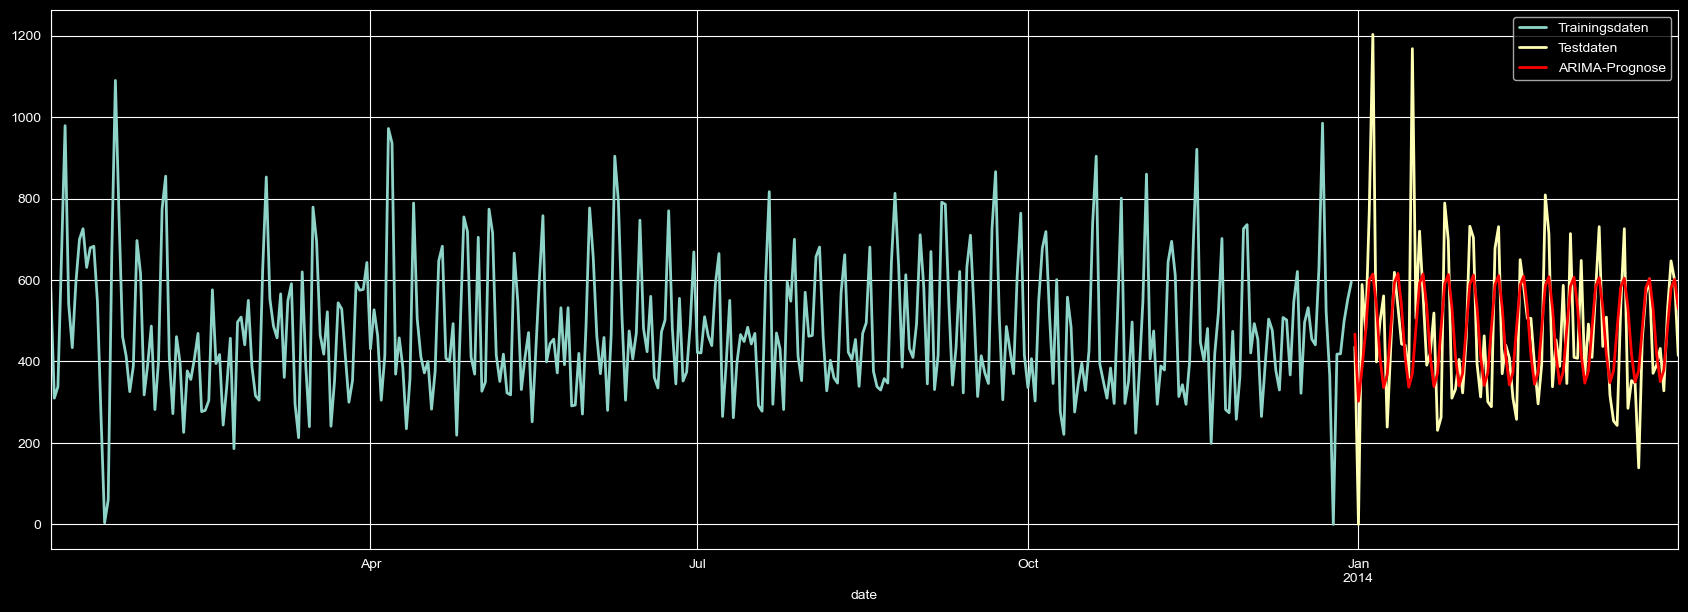

In [23]:
# ARIMA aus der Bibliothek darts importieren
from darts.models import ARIMA

# ARIMA-Modell mit (p, d, q) Parametern initialisieren
#arima_model = ARIMA(p=7, d=0, q=1)  # ARIMA(p, d, q)
# !!!! Diese zufällig gewählten Parameter sind deutlich besser als die oben ewig hergeleiteten!!!
arima_model = ARIMA(p=3, d=0, q=3)  # ARIMA(p, d, q)

# ARIMA-Modell mit den Trainingsdaten fitten
arima_model = arima_model.fit(train)

# Vorhersage für den Zeitraum der Testdaten (90 Tage = len(test))
arima_forecast = arima_model.predict(len(test))

# Prognose (rot) mit tatsächlichen Daten (blau) vergleichen
plt.figure(figsize=(21, 7))  # Größe der Grafik einstellen (Breite, Höhe)
train.plot(label='Trainingsdaten')
test.plot(label='Testdaten')
arima_forecast.plot(label='ARIMA-Prognose', color='red')


=> ARIMA versagt komplett, da wöchentliche Saisonalität ignoriert wird

Das gewählte ARIMA-Modell (nicht-saisonal) gibt jüngsten Beobachtungen das meiste Gewicht, fällt danach aber auf den Mittelwert zurück.
→ Funktioniert bei stabilen Daten, versagt bei plötzlichen Ausschlägen.

Informationen wie Aktionen, Feiertage oder Wochentags-Dummys würden helfen, große Sprünge zu erkennen und zu modellieren.

### Evaluierung => AIC/BIC und MAE/RMSE

In [12]:
from sklearn.metrics import mean_absolute_error

# Bewertung eines Modells
aic = arima_model.model.aic
mae = mean_absolute_error(test.values().flatten(), arima_forecast.values().flatten())
print("AIC: ", aic)
print("MAE: ", mae)


AIC:  4604.68658377732
MAE:  141.58151893523166


Faustregel:
- Wenn sowohl AIC/BIC als auch Validierungsfehler auf dasselbe (p, d, q) zeigen, hast du einen starken Kandidaten gefunden

AIC / BIC – Modellselektion:
- der absolute Wert an sich sagt nichts, sondern nur der Vergleich unter den Modellen
- Diese Metriken beantworten: Welches Modell ist das beste unter mehreren Kandidaten?
- je niedriger desto besser
- Faustregel ΔAIC: Unterschied < 2 → Modelle gleichwertig, > 10 → klarer Gewinner

Unterschied AIC/BIC:
- ARIMA macht Linearkombination
- je höher nun die gewählten Parameter p/q sind, desto mehr  mehr Tage in der Vergangenheit werden berücksichtigt
- => es gibt mehr Koeffizienten in der Linearkombination
- nun:
    - AIC bestraft jeden zusätzlichen Parameter gleich stark
    - BIC bestraft stärker, je größer der Datensatz (n geht in die Formel ein)
    - Ergebnis: BIC wählt bei großen Datensätzen tendenziell einfachere Modelle als AIC. In der Praxis berechnest du oft beide und schaust ob sie zum gleichen Schluss kommen.

MAE / RMSE – Vorhersagefehler:
- Diese Metriken beantworten: Wie groß sind meine Fehler im Durchschnitt?
- Beide messen die Abweichung zwischen vorhergesagten und tatsächlichen Werten – in der Einheit der Zielvariable
- MAE = Mean Absolute Error => Intuitiv: „Im Schnitt liege ich um X daneben"
- RMSE  = Root Mean Squared Error => Wie MAE, aber große Fehler werden stärker gewichtet (weil quadriert) => Sensitiver gegenüber Ausreißern als MAE

## SARIMA

Bestätige die saisonale Periode s
Stationarisiere mit normaler und saisonaler Differenzierung
Lies saisonale ACF/PACF-Spitzen ab, um P und Q zu schätzen
Suche im Gitter eine kleine Auswahl von (p, q) × (P, Q)
Passe die Modelle aus Schritt 4 an
Wähle das beste Modell nach AIC/BIC und Fehler auf dem Hold-Out-Set



### Schritt 1. Bestätige die saisonale Periode
#### Visuelle Inspektion der Trainingsdaten

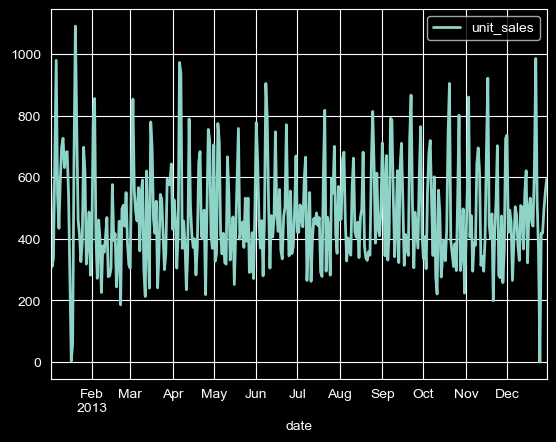

In [13]:
train.plot();                # visuelle Spitzen

### Wahl der saisonalen Ordnungen für SARIMA: Schritt 2-3
#### Untersuche die ACF auf Spitzen!

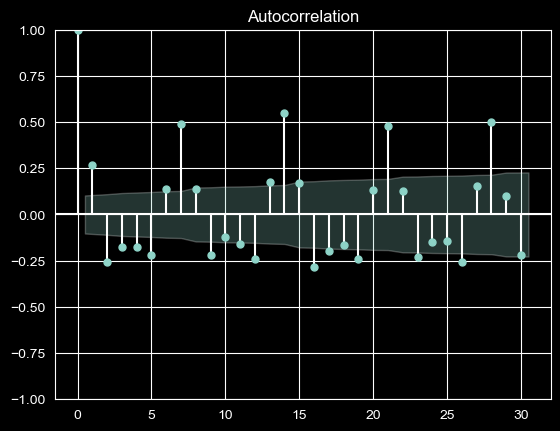

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(train.values().flatten(), lags=30)          # suche nach Spitzen bei s, 2s, 3s …
plt.show()

....................
.. Interpretation ..
....................

Starke positive Spitze bei Lag 1
- Die Verkäufe von gestern sind ein sehr guter Prädiktor für heute — klassisches Kurzzeitgedächtnis.

Regelmäßige positive Spitzen bei Lags 7, 14, 21, 28
- Ein klarer Wochenzyklus (Periode = 7 Tage). Jeden siebten Tag steigt die Autokorrelation wieder auf etwa 0,5, was den „gleichen Tag der Vorwoche“-Effekt bestätigt.

Alternierende negative Balken zwischen den wöchentlichen Spitzen
- Werte, die etwa eine halbe Woche auseinander liegen, bewegen sich in entgegengesetzte Richtungen — typisch für eine Reihe mit konstanter Saisonalität,


=> FAZIT: Saisonlänge = 7

In [15]:
# Saisonale Differenzierung mit Periode 7 Tage
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import numpy as np

# Darts-TimeSeries in ein einfaches 1D-Numpy-Array umwandeln
## Damit dieser Array nicht 2D ist (Werte aus Datum und unit_sales) wird mit "flatten" in 1D Array umgewandelt (nur unit_sales bleiben)
arr = train.values().flatten()   # Falls univariat, 1D-Array machen
arr

array([ 582.,  310.,  338.,  654.,  979.,  541.,  434.,  593.,  700.,
        726.,  631.,  679.,  683.,  547.,  265.,    4.,   60.,  667.,
       1090.,  760.,  461.,  413.,  326.,  389.,  697.,  616.,  318.,
        393.,  487.,  282.,  401.,  775.,  855.,  411.,  272.,  461.,
        397.,  226.,  377.,  356.,  407.,  469.,  277.,  280.,  304.,
        576.,  395.,  417.,  244.,  339.,  457.,  186.,  497.,  509.,
        441.,  550.,  388.,  316.,  305.,  627.,  853.,  554.,  487.,
        458.,  566.,  361.,  549.,  591.,  296.,  213.,  620.,  388.,
        240.,  779.,  695.,  465.,  418.,  522.,  241.,  353.,  544.,
        529.,  413.,  300.,  353.,  594.,  575.,  577.,  643.,  431.,
        527.,  463.,  305.,  415.,  972.,  936.,  369.,  458.,  386.,
        235.,  358.,  789.,  506.,  413.,  372.,  400.,  283.,  376.,
        647.,  683.,  408.,  400.,  493.,  219.,  491.,  755.,  719.,
        411.,  369.,  705.,  327.,  350.,  774.,  715.,  416.,  351.,
        418.,  323.,

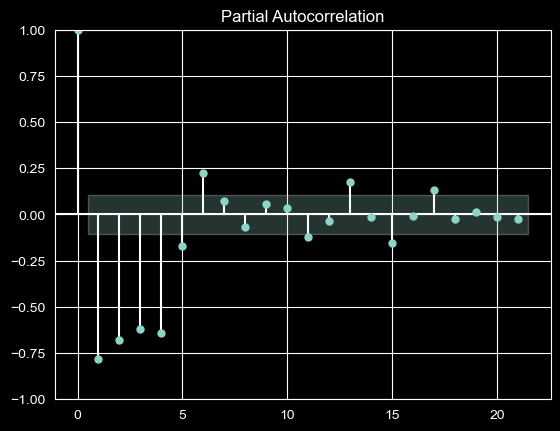

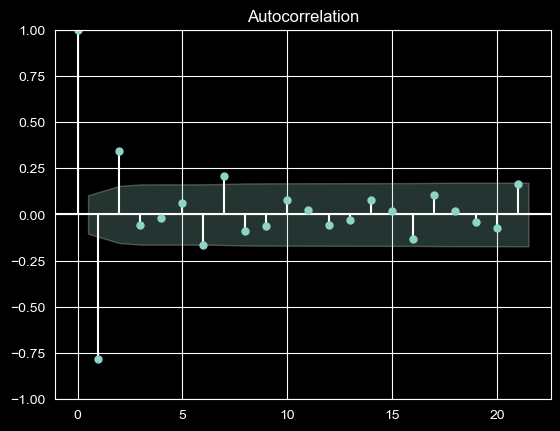

In [16]:
# Einfache saisonale Differenzierung mit Periode 7
## Das bedeutet: jeder Wert minus der Wert von vor 7 Tagen. Entfernt wöchentliche Saisonalität
diff_season = np.diff(arr, 7)

s = 7
plot_pacf(diff_season, lags=3*s)  # Lags s, 2s, ...
plot_acf(diff_season, lags=3*s)
plt.show()

ACF (oben)
- Spitzen bei 7, 14, 21 sind nun deutlich geringer
- => die wöchentliche Saisonalität ist verschwunden laut Learning Journey
- => einmalige Differenzierung hat gereicht
- => D = 1
    - eigentlich entferne ich meiner Ansicht nach die Saisonalität erst durch die zweite Differenzierung (siehe folgende Graphik)
    - allerdings Gefahr der Überdifferenzierung: D=2 kann die Zeitreihe zu stark verändern, Struktur geht verloren
    - => man sollte am Ende vlt Modelle mit D=1 und D=2 evaluieren und dann gegenüberstellen meiner Ansicht nach
-
- Die starke negative Autokorrelation bei Lag 1 deutet darauf hin, dass ein kurzer nicht-saisonaler MA(1)Term (q = 1) sinnvoll ist – genau wie zuvor bei ARIMA gewählt.
-
- in ARIMA hatten wir d=1 gesetzt und bleiben dabei

- !!!Fazit!!!: d=1, D=1, q=1


PACF (unten)
- Signifikante negative partielle Autokorrelationen bei Lags 1 bis 5, danach fällt alles in den Bereich der Unsicherheit zurück. Eine endliche AR-Struktur mit etwa p ≈ 5 reicht aus, um die verbleibende Korrelation zu erklären; höhere Lags tragen wenig bei. Das ähnelt unserer vorherigen Wahl bei ARIMA mit p=6.
- Erinnerung: Das „p“ gibt an, wie viele vergangene Beobachtungen das Modell zur Vorhersage des heutigen Werts

- Zur Wahl von P und Q: Nach der saisonalen Differenzierung (D = 1, m = 7) würdest du erwarten, dass verbleibende Saisonalität sich als signifikante Spitzen bei Lags 7, 14, 21 … in ACF/PACF zeigt. Hier sind nur noch kleine Spitzen zu sehen, die Wochenzyklen wurden also weitgehend entfernt. Deshalb setzen wir P = 1 und Q = 1 fest.


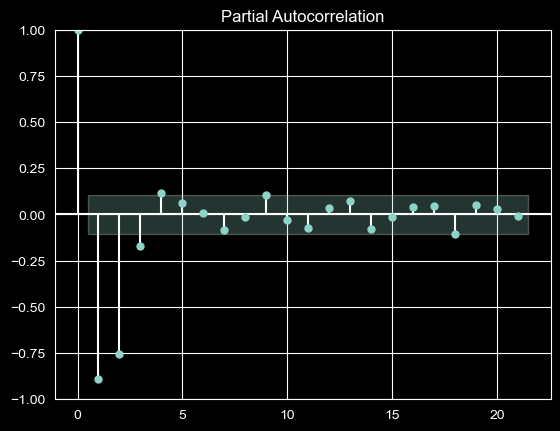

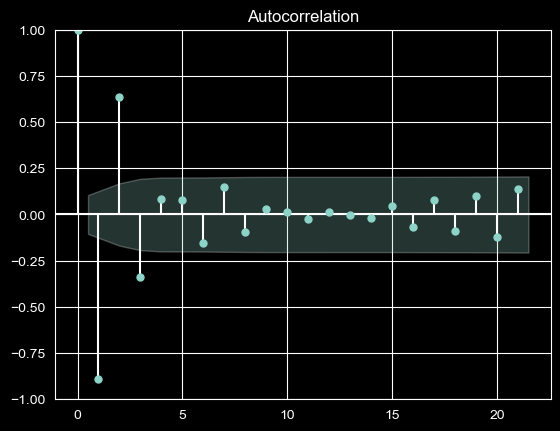

In [17]:
# Zweifache saisonale Differenzierung mit Periode 7
## Das bedeutet: jeder Wert minus der Wert von vor 7 Tagen. Entfernt wöchentliche Saisonalität
diff_season_2 = np.diff(np.diff(arr, 7), 7)

s = 7
plot_pacf(diff_season_2, lags=3*s)  # Lags s, 2s, ...
plot_acf(diff_season_2, lags=3*s)
plt.show()

Auswahl saisonaler Orders für SARIMA

### Mit nicht-saisonalen Orders kombinieren: Schritt 4

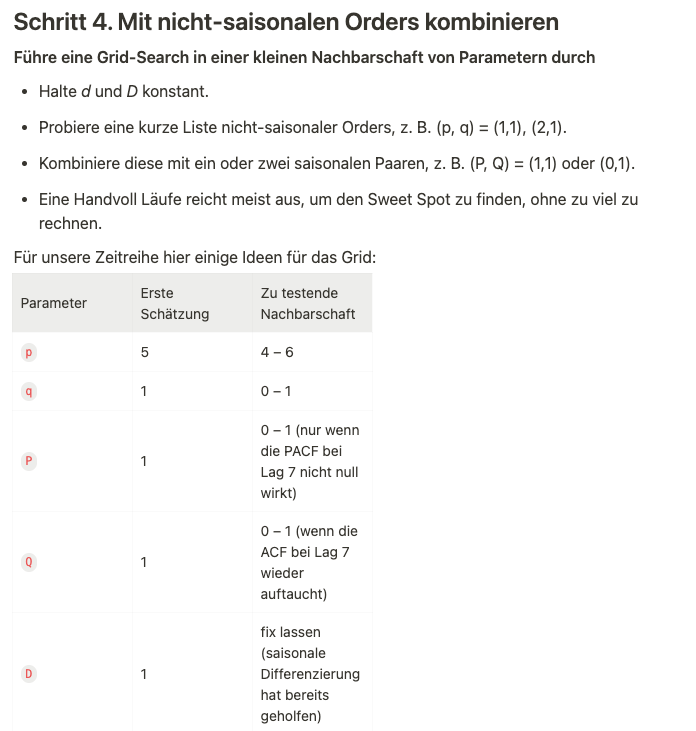

In [18]:
# sechs nicht-saisonale (p,d,q)-Kombinationen …
pdq      = [(4,0,0), (4,0,1), (5,0,0), (5,0,1), (6,0,0), (6,0,1)]

# … getestet gegen zwei saisonale (P,D,Q,m)-Einstellungen
seasonal = [(0,1,0,7), (0,1,1,7), (0,1,0,7), (0,1,1,7)]


### Fitting SARIMA: Step 5

<Axes: xlabel='date'>

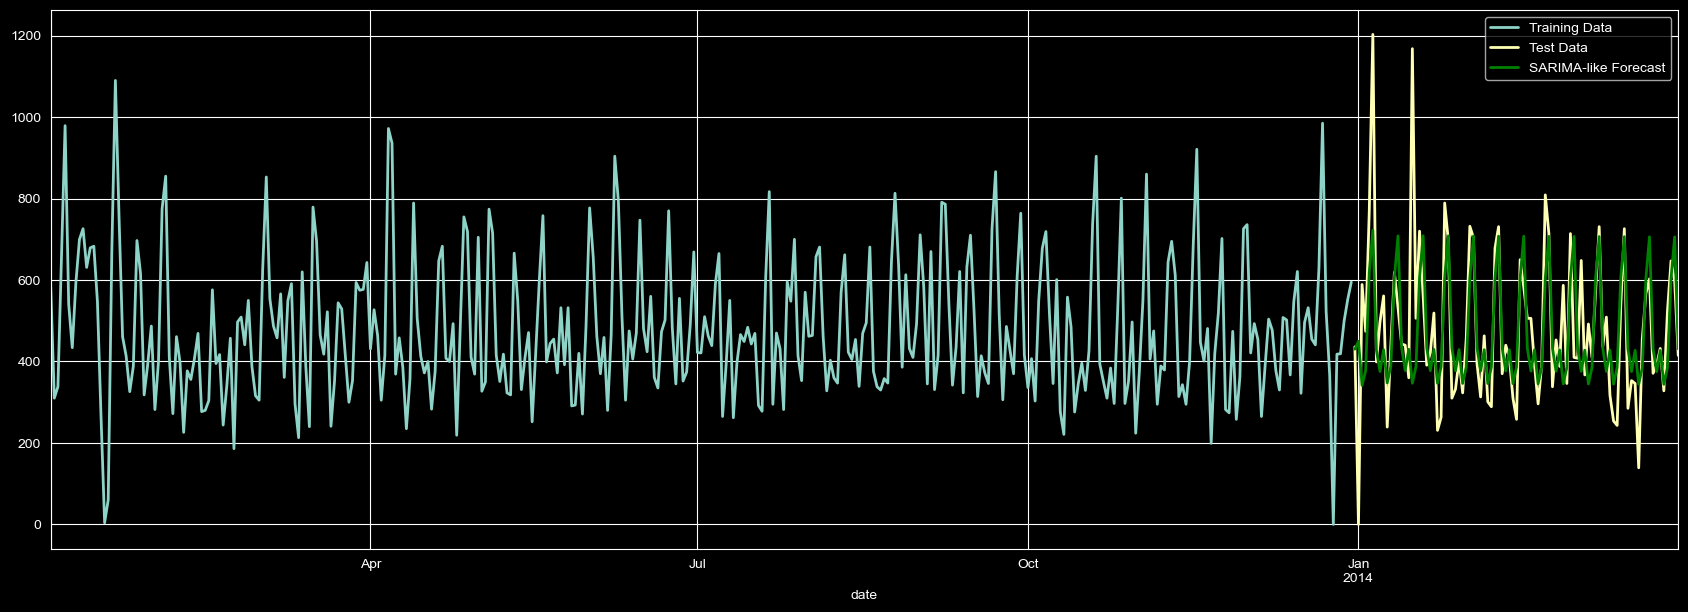

In [19]:
from darts.models import ARIMA

# Initialize ARIMA model with both (p, d, q) and (P, D, Q, m) parameters
# We will start by trying the guess of our analysis, we will then go to the grid as part of the exercise.
sarima_like_model = ARIMA(p=5, d=1, q=1, seasonal_order=(1, 1, 1, 7))

# Fit the ARIMA model with seasonality on the training data
sarima_like_model.fit(train)

# Forecast the next values (the same length as the test set)
sarima_forecast = sarima_like_model.predict(len(test))

# Plot SARIMA-like forecast vs actual data
plt.figure(figsize=(21, 7))  # Adjust the figure size (width, height)
train.plot(label='Training Data')
test.plot(label='Test Data')
sarima_forecast.plot(label='SARIMA-like Forecast', color='green')

### Evaluation
#### Model wie beschrieben

In [20]:
# Evaluate
aic = sarima_like_model.model.aic
mae   = mean_absolute_error(test.values().flatten() , sarima_forecast.values().flatten() )
print("AIC: ",aic)
print("MAE: ",mae)

AIC:  4422.470273742705
MAE:  97.85900839478985


Both the chart and the error numbers blow the plain ARIMA out of the water—the SARIMA traces the weekly peaks instead of flattening them. In short, adding the seasonal MA term let the model capture the 7-day rhythm that ARIMA kept missing.

#### Grid Search aus Step 5 mit vielen Parametern

In [21]:
from darts.models import ARIMA
from sklearn.metrics import mean_absolute_error

pdq      = [(4,0,0), (4,0,1), (5,0,0), (5,0,1), (6,0,0), (6,0,1)]
seasonal = [(0,1,0,7), (0,1,1,7)]

best_aic = float('inf')
best_cfg = None

for order in pdq:
    for s_order in seasonal:
        model = ARIMA(*order, seasonal_order=s_order)
        model.fit(train)

        pred = model.predict(len(test))
        mae  = mean_absolute_error(test.values().flatten(),
                                   pred.values().flatten())
        aic  = model.model.aic          # one extra line

        print(f"SARIMA{order}×{s_order}   AIC = {aic:.1f}   MAE = {mae:.2f}")

        if aic < best_aic:              # pick by lowest AIC
            best_aic, best_cfg = aic, (order, s_order)

print(f"\n🏆 Best model: SARIMA{best_cfg[0]}×{best_cfg[1]}   AIC = {best_aic:.1f}")


SARIMA(4, 0, 0)×(0, 1, 0, 7)   AIC = 4635.0   MAE = 179.45
SARIMA(4, 0, 0)×(0, 1, 1, 7)   AIC = 4418.8   MAE = 97.72
SARIMA(4, 0, 1)×(0, 1, 0, 7)   AIC = 4636.2   MAE = 180.16
SARIMA(4, 0, 1)×(0, 1, 1, 7)   AIC = 4418.6   MAE = 97.65
SARIMA(5, 0, 0)×(0, 1, 0, 7)   AIC = 4635.6   MAE = 180.09
SARIMA(5, 0, 0)×(0, 1, 1, 7)   AIC = 4420.0   MAE = 97.78
SARIMA(5, 0, 1)×(0, 1, 0, 7)   AIC = 4636.2   MAE = 179.66
SARIMA(5, 0, 1)×(0, 1, 1, 7)   AIC = 4420.8   MAE = 98.10
SARIMA(6, 0, 0)×(0, 1, 0, 7)   AIC = 4618.1   MAE = 166.84
SARIMA(6, 0, 0)×(0, 1, 1, 7)   AIC = 4420.2   MAE = 97.92
SARIMA(6, 0, 1)×(0, 1, 0, 7)   AIC = 4579.7   MAE = 162.79
SARIMA(6, 0, 1)×(0, 1, 1, 7)   AIC = 4422.2   MAE = 97.72

🏆 Best model: SARIMA(4, 0, 1)×(0, 1, 1, 7)   AIC = 4418.6


#### Mein Versuch

In [22]:
from darts.models import ARIMA
from sklearn.metrics import mean_absolute_error

pdq      = [(4,0,0), (4,0,1), (5,0,0), (5,0,1), (6,0,0), (6,0,1)]
seasonal = [(0,1,0,7), (0,1,1,7), (0,2,1,7)]

best_aic = float('inf')
best_cfg = None

for order in pdq:
    for s_order in seasonal:
        try:
            model = ARIMA(*order, seasonal_order=s_order)
            model.fit(train)
            pred = model.predict(len(test))
            mae  = mean_absolute_error(test.values().flatten(),
                                       pred.values().flatten())
            aic  = model.model.aic
            print(f"SARIMA{order}×{s_order}   AIC = {aic:.1f}   MAE = {mae:.2f}")
            if aic < best_aic:
                best_aic, best_cfg = aic, (order, s_order)
        except Exception as e:
            print(f"SARIMA{order}×{s_order}   FEHLER: {e}")

print(f"\n🏆 Best model: SARIMA{best_cfg[0]}×{best_cfg[1]}   AIC = {best_aic:.1f}")


SARIMA(4, 0, 0)×(0, 1, 0, 7)   AIC = 4635.0   MAE = 179.45
SARIMA(4, 0, 0)×(0, 1, 1, 7)   AIC = 4418.8   MAE = 97.72


/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


SARIMA(4, 0, 0)×(0, 2, 1, 7)   AIC = 4579.1   MAE = 201.87
SARIMA(4, 0, 1)×(0, 1, 0, 7)   AIC = 4636.2   MAE = 180.16
SARIMA(4, 0, 1)×(0, 1, 1, 7)   AIC = 4418.6   MAE = 97.65


/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


SARIMA(4, 0, 1)×(0, 2, 1, 7)   AIC = 4581.5   MAE = 200.02
SARIMA(5, 0, 0)×(0, 1, 0, 7)   AIC = 4635.6   MAE = 180.09
SARIMA(5, 0, 0)×(0, 1, 1, 7)   AIC = 4420.0   MAE = 97.78


...

SARIMA(5, 0, 1)×(0, 2, 1, 7)   AIC = 4558.4   MAE = 198.74
SARIMA(6, 0, 0)×(0, 1, 0, 7)   AIC = 4618.1   MAE = 166.84
SARIMA(6, 0, 0)×(0, 1, 1, 7)   AIC = 4420.2   MAE = 97.92


/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


SARIMA(6, 0, 0)×(0, 2, 1, 7)   AIC = 4563.8   MAE = 184.38
SARIMA(6, 0, 1)×(0, 1, 0, 7)   AIC = 4579.7   MAE = 162.79
SARIMA(6, 0, 1)×(0, 1, 1, 7)   AIC = 4422.2   MAE = 97.72


/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


SARIMA(6, 0, 1)×(0, 2, 1, 7)   AIC = 4527.9   MAE = 176.61

🏆 Best model: SARIMA(4, 0, 1)×(0, 1, 1, 7)   AIC = 4418.6


Diese beiden Warnings treten fast immer zusammen bei D=2 auf – ein weiteres Zeichen dass D=2 hier überdifferenziert und das Modell numerisch instabil macht. Bestätigt deine Wahl von D=1.

### Common Trouble Shoothing

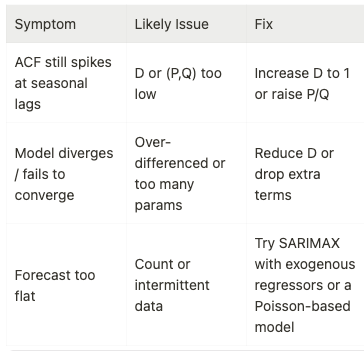

- Start simple: (p,d,q) from ARIMA + (P,D,Q) = (1,1,1) and iterate.
- Let AIC/BIC & validation error guide refinement, just like with ARIMA.
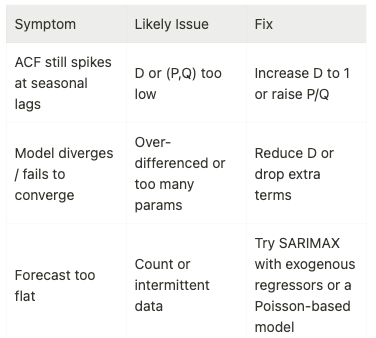